### **Model Training**

L'obiettivo principale di questa sezione è sviluppare, addestrare e confrontare diverse architetture di Machine Learning e Deep Learning per risolvere il task di **Classificazione Binaria**: prevedere se una richiesta di pizza avrà successo (True) o meno (False).

Dato che il dataset è caratterizzato da **eterogeneità** (feature testuali sparse + metadati numerici densi) e da un significativo **sbilanciamento** delle classi (~25% successi), l'analisi seguirà più strategie per raggiungere l'obiettivo finale e confrontare le prestazioni delle varie architetture.

In [1]:
# =========================
# Librerie standard
# =========================
import warnings
import pickle
import joblib

warnings.filterwarnings("ignore")

# =========================
# Numerical & data handling
# =========================
import numpy as np
import pandas as pd
import scipy.sparse
from scipy.sparse import hstack, csr_matrix
from collections import Counter

# =========================
# NLP
# =========================
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sentence_transformers import SentenceTransformer

# =========================
# Feature extraction / decomposition
# =========================
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import NMF
from sklearn.preprocessing import StandardScaler, FunctionTransformer

# =========================
# Model selection
# =========================
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

# =========================
# Models
# =========================
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier
)
from xgboost import XGBClassifier

# =========================
# Metrics
# =========================
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score,
    precision_recall_curve,
    average_precision_score
)

# =========================
# Imbalanced learning
# =========================
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# =========================
# Visualizzazione
# =========================
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# Configurazioni
# =========================
SEED = 42
np.random.seed(SEED)

TEST_SIZE = 0.2
N_FOLDS = 5


In [2]:
# 1. CARICAMENTO DATI
print("Caricamento dataset e matrici...")

# Carica il DataFrame
df = pd.read_pickle('data/train/01_train_enriched.pkl')

# Carica la Matrice Sparsa
text_features_sparse = scipy.sparse.load_npz('data/train/01_text_features_sparse.npz')

# Carica i nomi delle feature per analisi
with open('data/train/01_transformers.pkl', 'rb') as f:
    transformers = pickle.load(f)
    tfidf_vec = transformers['tfidf_vec']

# 2. SELEZIONE FEATURE NUMERICHE
topic_cols = [c for c in df.columns if 'topic_' in c]

numeric_cols = [
    'account_age_days', 'num_comments', 'karma', 'num_subreddits', 
    'text_len_char', 'word_count', 'processed_text_length', 
    'vader_compound', 'vader_pos', 'vader_neg',
    'kw_struggle', 'kw_family', 'kw_politeness', 'kw_urgency', 'kw_money_concrete',
    'offers_reciprocity', 'exclamation_count', 'question_count', 'has_emoji',
    'hour', 'is_weekend', 'is_month_end'
] + topic_cols

# Verifica e seleziona le feature disponibili
available_cols = [col for col in numeric_cols if col in df.columns]
numeric_features = df[available_cols].fillna(0)

# 3. CONSOLIDAMENTO FINALE
numeric_sparse = csr_matrix(numeric_features.values)

# Dataset Finale per il Training
X_final = hstack([text_features_sparse, numeric_sparse])
y_final = df['target']

print("\n--- CARICAMENTO COMPLETATO ---")
print(f"Dataset shape finale: {X_final.shape}")
print(f"Colonne finali del dataset: {available_cols}")
print(f"Pronto per il training del modello.")

Caricamento dataset e matrici...

--- CARICAMENTO COMPLETATO ---
Dataset shape finale: (4040, 2071)
Colonne finali del dataset: ['account_age_days', 'num_comments', 'karma', 'num_subreddits', 'text_len_char', 'word_count', 'processed_text_length', 'vader_compound', 'vader_pos', 'vader_neg', 'kw_struggle', 'kw_family', 'kw_politeness', 'kw_urgency', 'kw_money_concrete', 'offers_reciprocity', 'exclamation_count', 'question_count', 'hour', 'is_weekend', 'is_month_end']
Pronto per il training del modello.


### **Costruzione della Matrice Finale e Data Splitting**

In questa fase avviene l'**assemblaggio** finale del dataset ($X$) e la **suddivisione** per l'addestramento. Poiché il modello dovrà apprendere simultaneamente da feature testuali (ad alta dimensionalità e sparse) e feature numeriche (dense), è necessario adottare una strategia di fusione efficiente.

**Crezione della Matrice Sparsa Ibrida**

Le feature numeriche (_es. karma, account_age_) sono state convertite in formato sparso (`csr_matrix`) per essere compatibili con la matrice TF-IDF generata in precedenza.
Attraverso un'operazione di **Horizontal Stacking** (`hstack`), le due matrici sono state concatenate lateralmente.
Il risultato è una singola matrice $X$ dove:
   - Le prime $N$ colonne rappresentano i **token** del testo (TF-IDF).
   - Le successive colonne rappresentano i metadati numerici e i topic.

$$X_{final} = [X_{tfidf} \ | \ X_{numeric}]$$

**Split del Dataset**

Il dataset è stato suddiviso in set di addestramento (80%) e test (20%). Data la natura sbilanciata del target (solo il ~25% delle richieste ha successo), è stato utilizzato il parametro `stratify=y`. Questo garantisce che la proporzione originale di classi (Successo/Fallimento) venga preservata identica sia nel training set che nel test set, prevenendo bias nella valutazione.

In [3]:
# Preparazione delle features
def prepare_final_data(numeric_df, sparse_text_matrix, target):
    print("\nPreparazione X e y finali...")
    
    # Conversione delle feature numeriche in matrice sparsa per unirle al testo
    numeric_sparse = csr_matrix(numeric_df.values)
    
    # Unione Orizzontale: [Testo TF-IDF] + [Numeri]
    X_final = hstack([sparse_text_matrix, numeric_sparse])
    y_final = target.values
    
    print(f"Shape finale X: {X_final.shape}")
    return X_final, y_final

X, y = prepare_final_data(numeric_features, text_features_sparse, df['target'])

# Split Stratificato (mantiene la proporzione di successi/fallimenti)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


Preparazione X e y finali...
Shape finale X: (4040, 2071)


### **Training e Valutazione dei Modelli**

Per l'addestramento dei modelli, sono stati utilizzati diversi algoritmi di classificazione, selezionati per coprire diverse famiglie di apprendimento statistico: modelli lineari (Logistic Regression, SVM), modelli basati su alberi (Random Forest, Gradient Boosting) e modelli probabilistici (Naive Bayes).

**Metodologia di Validazione**

L'analisi si basa su una doppia verifica:

   - **1. Stratified K-Fold Cross-Validation (5-Fold)**: valuta la stabilità del modello durante il training. Si utilizza l'**F1-Score** come metrica principale, poiché è più sensibile dell'accuratezza nel bilanciare Precision e Recall su classi sbilanciate.
   - **2. Test Set Hold-out**: Una valutazione finale sul 20% dei dati mai visti dal modello, misurando **ROC-AUC** (capacità di ordinare le probabilità) e **Average Precision**.


TRAINING MODELLI

Training Logistic Regression...
  -> CV F1: 0.3214 (+/- 0.0456)
  -> Test ROC-AUC: 0.5923
  -> Test F1: 0.3357

Training Random Forest...
  -> CV F1: 0.0000 (+/- 0.0000)
  -> Test ROC-AUC: 0.6063
  -> Test F1: 0.0000

Training Gradient Boosting...
  -> CV F1: 0.1404 (+/- 0.0454)
  -> Test ROC-AUC: 0.5853
  -> Test F1: 0.1429

Training SVM (Linear)...
  -> CV F1: 0.3252 (+/- 0.0281)
  -> Test ROC-AUC: 0.5934
  -> Test F1: 0.3501

Training Naive Bayes...
  -> CV F1: 0.3428 (+/- 0.0592)
  -> Test ROC-AUC: 0.5691
  -> Test F1: 0.3872


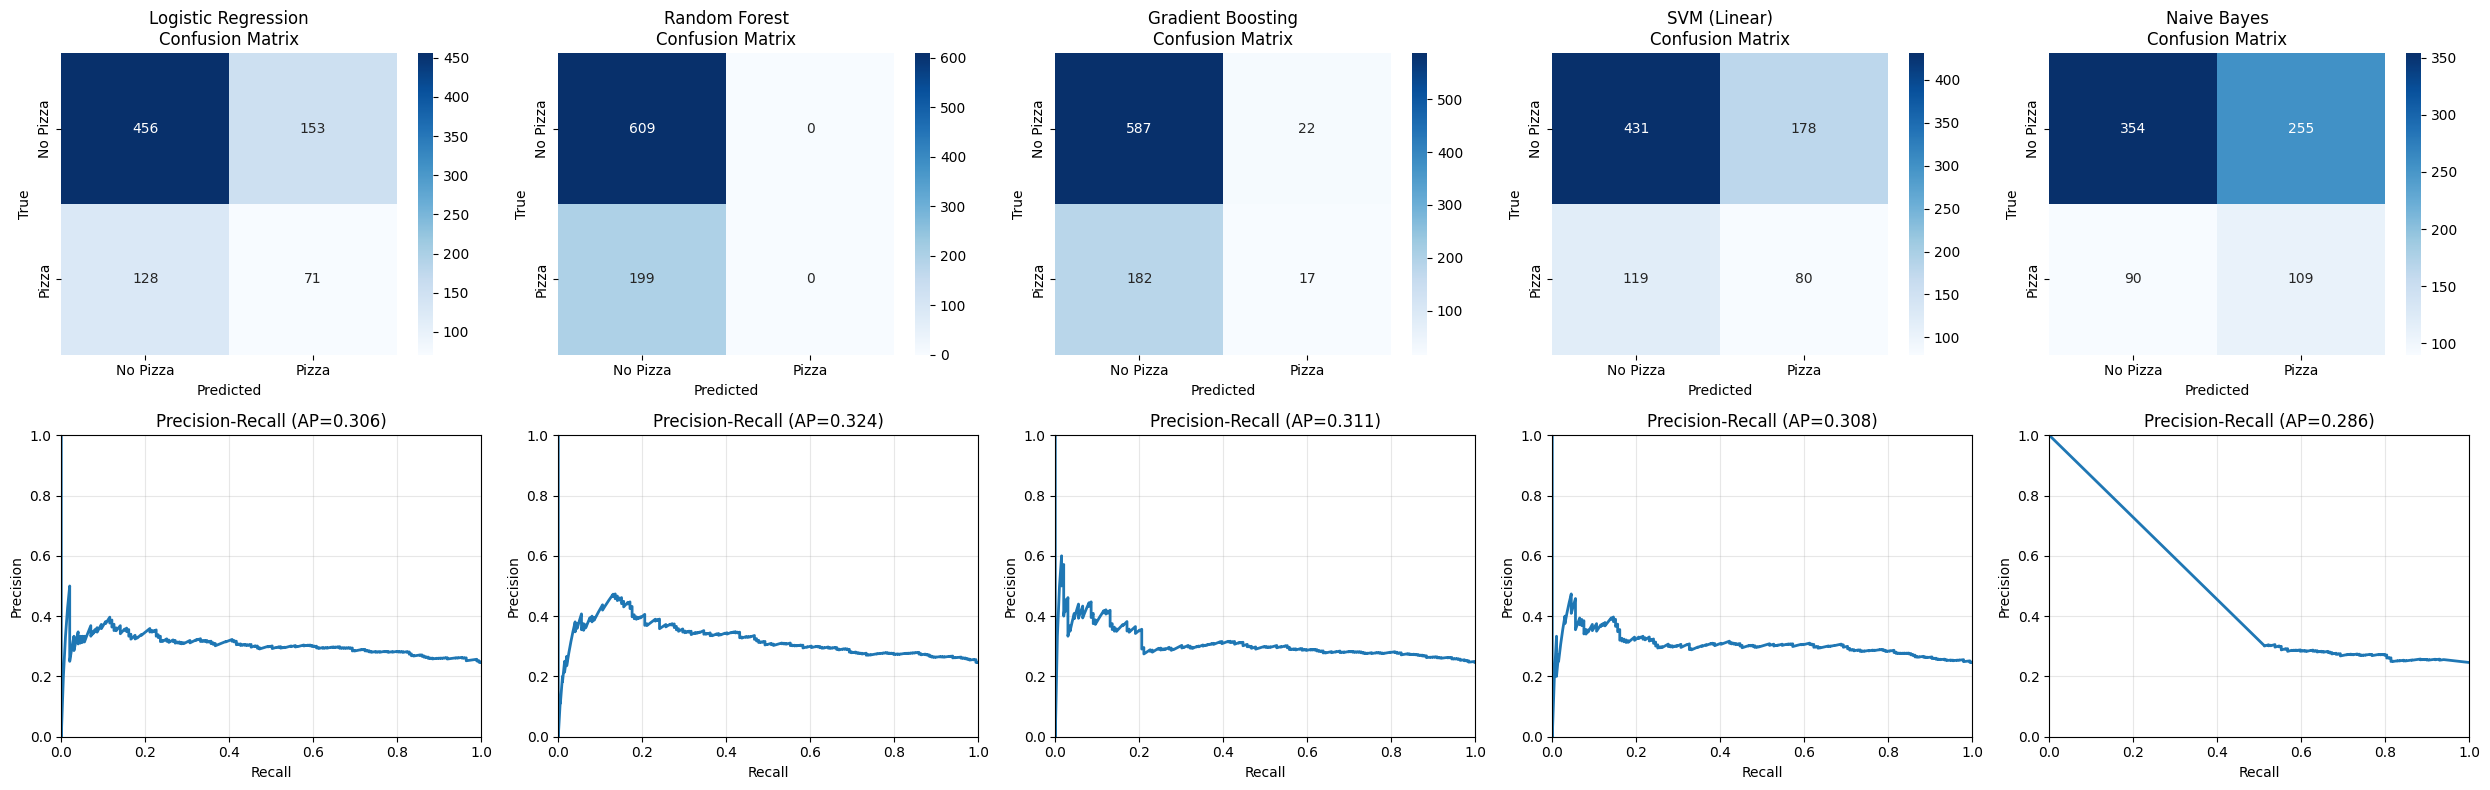

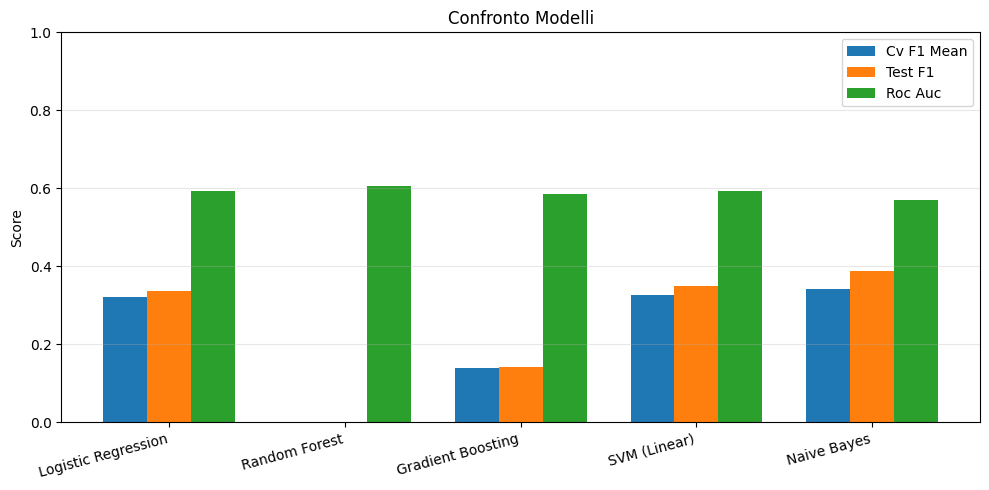

In [ ]:
from sklearn.pipeline import Pipeline

# Training e valutazione
def train_and_evaluate_no_balance(X_train, X_test, y_train, y_test):
    print("\n" + "="*60)
    print("TRAINING MODELLI")
    print("="*60)
    
    results = {}
    
    # Transformer per convertire matrice sparsa in densa (solo per Naive Bayes)
    to_dense = FunctionTransformer(lambda x: x.toarray(), accept_sparse=True)
    
    # 1. Pipeline per Modelli Lineari (Solo Scaler)
    pipeline_linear = lambda model: Pipeline([
        ('scaler', StandardScaler(with_mean=False)), 
        ('clf', model)
    ])
    
    # 2. Pipeline per Alberi (Diretta)
    pipeline_tree = lambda model: Pipeline([
        ('clf', model)
    ])
    
    # 3. Pipeline per Naive Bayes (Scaler -> Dense -> GaussianNB)
    pipeline_nb = Pipeline([
        ('scaler', StandardScaler(with_mean=False)),
        ('to_dense', to_dense), 
        ('clf', GaussianNB())
    ])

    models_config = {
        'Logistic Regression': {
            'pipe': pipeline_linear(LogisticRegression(C=0.1, max_iter=1000, random_state=42))
        },
        'Random Forest': {
            'pipe': pipeline_tree(RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1))
        },
        'Gradient Boosting': {
            'pipe': pipeline_tree(GradientBoostingClassifier(n_estimators=150, max_depth=4, random_state=42))
        },
        'SVM (Linear)': {
            'pipe': pipeline_linear(SVC(kernel='linear', probability=True, random_state=42))
        },
        'Naive Bayes': {
            'pipe': pipeline_nb
        }
    }

    for name, config in models_config.items():
        print(f"\nTraining {name}...")
        pipeline = config['pipe']
        
        # 1. Cross-Validation
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        
        cv_scores_f1 = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1')
        print(f"  -> CV F1: {cv_scores_f1.mean():.4f} (+/- {cv_scores_f1.std()*2:.4f})")
        
        # 2. Fit Finale
        pipeline.fit(X_train, y_train)
        
        # 3. Predizione
        y_pred = pipeline.predict(X_test)
        
        # Gestione probabilità
        try:
            y_proba = pipeline.predict_proba(X_test)[:, 1]
        except AttributeError:
            y_proba = pipeline.decision_function(X_test)
        
        # 4. Metriche Test
        roc = roc_auc_score(y_test, y_proba)
        f1 = f1_score(y_test, y_pred)
        ap = average_precision_score(y_test, y_proba)
        
        print(f"  -> Test ROC-AUC: {roc:.4f}")
        print(f"  -> Test F1: {f1:.4f}")
        
        # Salvataggio risultati
        results[name] = {
            'model': pipeline,
            'cv_f1_mean': cv_scores_f1.mean(),
            'cv_f1_std': cv_scores_f1.std(),
            'test_f1': f1,
            'roc_auc': roc,
            'avg_precision': ap,
            'y_pred': y_pred,
            'y_proba': y_proba
        }
        
    return results

# Plotting dei risultati
def plot_results(results, y_test):

    n_models = len(results)
    fig, axes = plt.subplots(2, n_models, figsize=(5*n_models, 8))
    
    for i, (name, res) in enumerate(results.items()):
        # Confusion Matrix
        ax1 = axes[0, i] if n_models > 1 else axes[0]
        cm = confusion_matrix(y_test, res['y_pred'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
                    xticklabels=['No Pizza', 'Pizza'],
                    yticklabels=['No Pizza', 'Pizza'])
        ax1.set_title(f'{name}\nConfusion Matrix')
        ax1.set_ylabel('True')
        ax1.set_xlabel('Predicted')
        
        # Precision-Recall Curve
        ax2 = axes[1, i] if n_models > 1 else axes[1]
        precision, recall, _ = precision_recall_curve(y_test, res['y_proba'])
        ax2.plot(recall, precision, linewidth=2)
        ax2.set_xlabel('Recall')
        ax2.set_ylabel('Precision')
        ax2.set_title(f'Precision-Recall (AP={res["avg_precision"]:.3f})')
        ax2.set_xlim([0, 1])
        ax2.set_ylim([0, 1])
        ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Summary bar plot
    fig, ax = plt.subplots(figsize=(10, 5))
    metrics = ['cv_f1_mean', 'test_f1', 'roc_auc']
    x = np.arange(len(results))
    width = 0.25
    
    for j, metric in enumerate(metrics):
        values = [res[metric] for res in results.values()]
        ax.bar(x + j*width, values, width, label=metric.replace('_', ' ').title())
    
    ax.set_xticks(x + width)
    ax.set_xticklabels([name[:20] for name in results.keys()], rotation=15, ha='right')
    ax.set_ylabel('Score')
    ax.set_title('Confronto Modelli')
    ax.legend()
    ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

# Esecuzione
results_unbalanced = train_and_evaluate_no_balance(X_train, X_test, y_train, y_test) 

# Visualizzazione (riutilizzando la tua funzione di plot esistente)
plot_results(results_unbalanced, y_test)

### **Analisi dei risultati**

L'analisi comparativa delle performance evidenzia una sfida significativa nella classificazione: il segnale predittivo è **debole**, con metriche che suggeriscono una notevole **difficoltà** nel distinguere nettamente le due classi. Tuttavia, emergono differenze sostanziali nel comportamento dei diversi algoritmi.

Il risultato più interessante ed educativo è quello del **Random Forest**.

- **F1-Score = 0.00**: guardando la matrice di confusione, il modello ha predetto **0 pizze**. Ha classificato tutti i 199 casi positivi come negativi. Questo accade perché, nel tentativo di massimizzare l'accuratezza globale, la strategia più sicura è dire sempre "no", dato che sono la maggioranza.
- **ROC-AUC = 0.6063 (il migliore)**: il modello ha imparato a distinguere le classi. Sa assegnare una probabilità più bassa all'utente che non riceverà la pizza e una leggermente più alta a quello che la riceverà. Il **problema** risiede nella soglia di decisione standard (del 50%). Poiché il modello è cauto, magari assegna al caso positivo una probabilità del 30% o 40%. Per la soglia standard è "no", ma per la curva ROC (che testa tutte le soglie) è un buon segnale.

Per quanto riguarda il **Naive Bayes**, si comporta in modo opposto agli alberi.

- **F1-Score = 0.3872**: è il modello con l'F1-Score più alto. Dalla matrice di confusione, si può osservare come abbia trovato molti più True positives degli altri modelli (109) ma, per trovarli, ha sbagliato 255 volte (False Positives), predicendo pizza a chi non l'ha ricevuta.
- Quindi, questo modello alza la Recall, ma distrugge la Precision. L'AUC più bassa (0.569) conferma che, sebbene ne indovini tanti, non è molto raffinato nell'ordinamento.

I Modelli Lineari (**Logistic Regression e SVM**) si confermano i modelli più stabili ed equilibrati in questo contesto.

- Hanno performance quasi identiche (F1-Score 0.33-0.35, AUC circa 0.59).
- Tuttavia, un F1-Score di 0.33 è ancora basso per un'applicazione reale: si sta perdendo la maggior parte delle opportunità di identificare chi riceverà la pizza.

Infine, il modello **Gradient Boosting** ha mostrato capacità di apprendimento limitata ma presente, superando il collasso totale del Random Forest, ma rimanendo molto inefficace.

- **F1-Score: 0.1429** e **ROC-AUC** 0.5853: A differenza del Random Forest (che non ha trovato nessuna pizza), il Gradient Boosting è riuscito a identificare correttamente 17 richieste vincenti su 199. Questo dimostra che la tecnica di boosting riesce a scovare pattern anche nella classe minoritaria.

- Il modello è **molto conservativo**: ha sbagliato poco quando ha detto "No" (pochi Falsi Positivi), ma ha perso il 91% delle pizze reali (182 Falsi Negativi).

### **Gestione dello Sbilanciamento**

Data la natura sbilanciata del dataset e i risultati visti in precedenza, è stata posta particolare attenzione alla **gestione delle classi minoritarie** e alla corretta valutazione delle performance.

**Strategia di Modellazione**

Per ogni algoritmo è stata costruita una **Pipeline** specifica utilizzando la libreria `imblearn`. Questo garantisce che le operazioni di preprocessing (come il sovracampionamento) avvengano correttamente all'interno della **Cross-Validation**, evitando il data leakage.

   - **1. Gestione dello sbilanciamento**: vengono utilizzati due metodi diversi.
      - **SMOTE (Synthetic Minority Over-sampling Technique)**: utilizzato per i modelli lineari (Logistic Regression, SVM) e Naive Bayes. Genera esempi sintetici della classe minoritaria ("Successo") interpolando tra vicini prossimi, bilanciando il training set.
      - **Class Weights**: per i modelli basati su alberi (Random Forest, Gradient Boosting), si è preferito utilizzare il parametro `class_weight='balanced'`, che penalizza maggiormente gli errori sulla classe minoritaria senza alterare la distribuzione dei dati originali.
   - **2. Configurazione dei modelli**:
      - **Logistic Regression & SVM**: modelli lineari che richiedono scalatura delle feature (`StandardScaler`) per funzionare correttamente.
      - **Random Forest & Gradient Boosting**: modelli non lineari robusti, capaci di catturare interazioni complesse tra le feature.
      - **Naive Bayes**: un modello probabilistico semplice usato come baseline aggiuntiva (richiede la conversione della matrice sparsa in densa).

In [9]:
def analyze_smote_impact(X, y):
    print("\n" + "="*40)
    print("ANALISI BILANCIAMENTO SMOTE")
    print("="*40)
    
    # 1. Situazione Iniziale
    counter_original = Counter(y)
    print(f"Originale: {counter_original}")
    
    # Calcolo matematico di quanti ne verranno generati
    majority_count = max(counter_original.values())
    minority_count = min(counter_original.values())
    samples_created = majority_count - minority_count
    
    print(f"Classe Maggioritaria: {majority_count}")
    print(f"Classe Minoritaria:   {minority_count}")
    print(f"SMOTE genererà:       +{samples_created} campioni sintetici")
    
    # 2. Simulazione Applicazione
    sm = SMOTE(random_state=42)
    X_res, y_res = sm.fit_resample(X, y)
    
    counter_res = Counter(y_res)
    print(f"Dopo SMOTE: {counter_res}")
    print(f"Totale campioni training: {len(y)} -> {len(y_res)}")
    print("="*40 + "\n")

# Esegui l'analisi sui tuoi dati di train
analyze_smote_impact(X_train, y_train)


ANALISI BILANCIAMENTO SMOTE
Originale: Counter({np.int64(0): 2437, np.int64(1): 795})
Classe Maggioritaria: 2437
Classe Minoritaria:   795
SMOTE genererà:       +1642 campioni sintetici
Dopo SMOTE: Counter({np.int64(0): 2437, np.int64(1): 2437})
Totale campioni training: 3232 -> 4874




TRAINING MODELLI

Training Logistic Regression...
  -> CV F1: 0.3241 (+/- 0.0311)
  -> Test ROC-AUC: 0.5955
  -> Test F1: 0.3551

Training Random Forest...
  -> CV F1: 0.2494 (+/- 0.0356)
  -> Test ROC-AUC: 0.6133
  -> Test F1: 0.2175

Training Gradient Boosting...
  -> CV F1: 0.1404 (+/- 0.0454)
  -> Test ROC-AUC: 0.5853
  -> Test F1: 0.1429

Training SVM (Linear)...
  -> CV F1: 0.3252 (+/- 0.0281)
  -> Test ROC-AUC: 0.5934
  -> Test F1: 0.3501

Training Naive Bayes...
  -> CV F1: 0.2218 (+/- 0.0506)
  -> Test ROC-AUC: 0.5585
  -> Test F1: 0.2949


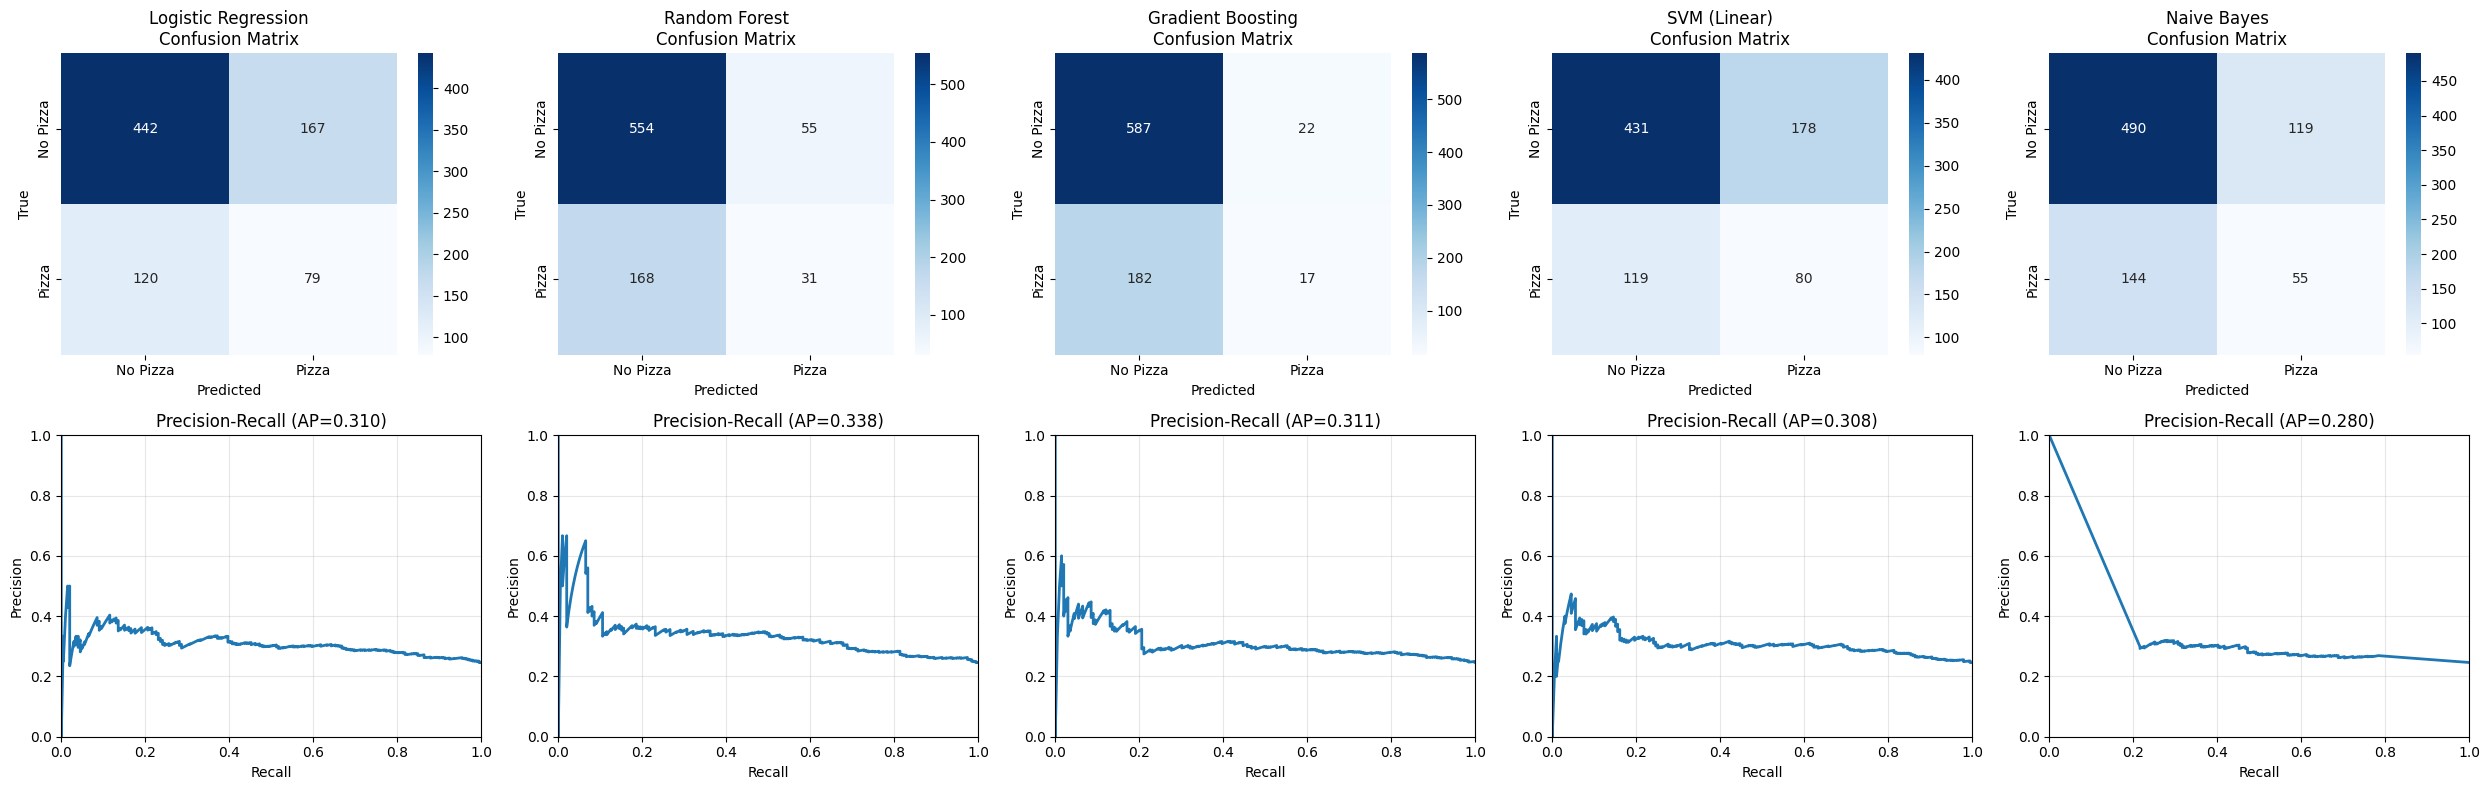

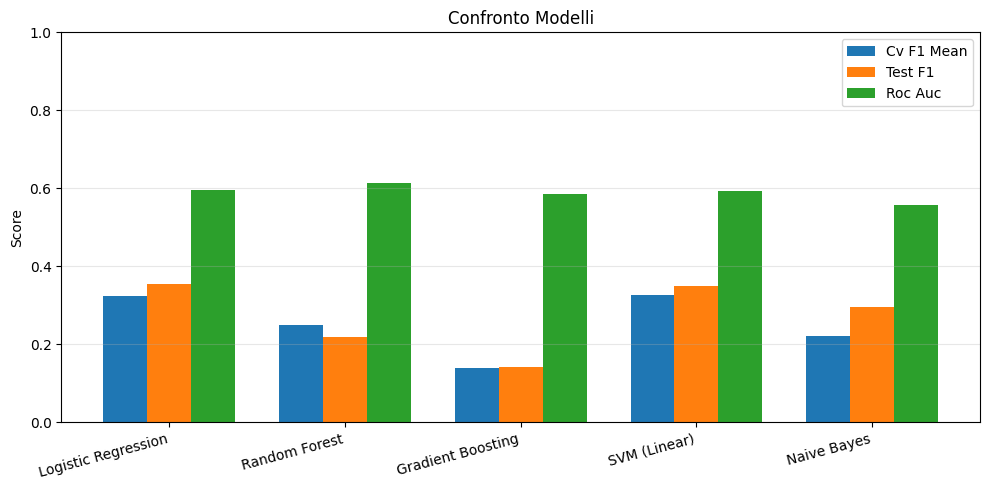

In [ ]:
# Training e valutazione
def train_and_evaluate(X_train, X_test, y_train, y_test):
    print("\n" + "="*60)
    print("TRAINING MODELLI")
    print("="*60)
    
    results = {}
    
    # Transformer per convertire matrice sparsa in densa (solo per Naive Bayes)
    to_dense = FunctionTransformer(lambda x: x.toarray(), accept_sparse=True)
    
    # 1. Pipeline per Modelli Lineari (Scaler + SMOTE)
    pipeline_linear = lambda model: ImbPipeline([
        ('scaler', StandardScaler(with_mean=False)), 
        ('smote', SMOTE(random_state=42, k_neighbors=5)),
        ('clf', model)
    ])
    
    # 2. Pipeline per Alberi (Solo Class Weight)
    pipeline_tree = lambda model: ImbPipeline([
        ('clf', model)
    ])
    
    # 3. Pipeline Speciale per Naive Bayes (SMOTE -> Dense -> GaussianNB)
    # GaussianNB non accetta matrici sparse, quindi si usa to_dense prima del clf
    pipeline_nb = ImbPipeline([
        ('scaler', StandardScaler(with_mean=False)),
        ('smote', SMOTE(random_state=42)),
        ('to_dense', to_dense), 
        ('clf', GaussianNB())
    ])

    models_config = {
        'Logistic Regression': {
            'pipe': pipeline_linear(LogisticRegression(C=0.1, max_iter=1000, class_weight='balanced', random_state=42))
        },
        'Random Forest': {
            'pipe': pipeline_tree(RandomForestClassifier(n_estimators=200, max_depth=15, class_weight='balanced_subsample', random_state=42, n_jobs=-1))
        },
        'Gradient Boosting': {
            'pipe': pipeline_tree(GradientBoostingClassifier(n_estimators=150, max_depth=4, random_state=42))
        },
        'SVM (Linear)': {
            'pipe': pipeline_linear(SVC(kernel='linear', probability=True, class_weight='balanced', random_state=42))
        },
        'Naive Bayes': {
            'pipe': pipeline_nb
        }
    }

    for name, config in models_config.items():
        print(f"\nTraining {name}...")
        pipeline = config['pipe']
        
        # 1. Cross-Validation
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        
        # Calcolo F1 per evitare il KeyError
        cv_scores_f1 = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1')
        print(f"  -> CV F1: {cv_scores_f1.mean():.4f} (+/- {cv_scores_f1.std()*2:.4f})")
        
        # 2. Fit Finale
        pipeline.fit(X_train, y_train)
        
        # 3. Predizione
        y_pred = pipeline.predict(X_test)
        
        # Gestione probabilità
        try:
            y_proba = pipeline.predict_proba(X_test)[:, 1]
        except AttributeError:
            y_proba = pipeline.decision_function(X_test)
        
        # 4. Metriche Test
        roc = roc_auc_score(y_test, y_proba)
        f1 = f1_score(y_test, y_pred)
        ap = average_precision_score(y_test, y_proba)
        
        print(f"  -> Test ROC-AUC: {roc:.4f}")
        print(f"  -> Test F1: {f1:.4f}")
        
        # Salvataggio risultati
        results[name] = {
            'model': pipeline,
            'cv_f1_mean': cv_scores_f1.mean(),
            'cv_f1_std': cv_scores_f1.std(),
            'test_f1': f1,
            'roc_auc': roc,
            'avg_precision': ap,
            'y_pred': y_pred,
            'y_proba': y_proba
        }
        
    return results

# Training e valutazione
results = train_and_evaluate(X_train, X_test, y_train, y_test) 

# Visualizzazione
plot_results(results, y_test)

### **Analisi dei Risultati: Confronto Baseline vs SMOTE**

**Sintesi delle performance**

Confrontando i risultati ottenuti con il dataset sbilanciato ("Baseline") e quelli dopo l'applicazione di **SMOTE**, emergono evidenze cruciali sull'efficacia del sovracampionamento:

- **1. Miglior Modello: Logistic Regression**: si conferma il modello più solido. L'introduzione di SMOTE ha portato un incremento dell'**F1-Score** (da 0.336 a **0.355**) e un **ROC-AUC** competitivo (**0.596**). Offre il miglior compromesso tra Precision e Recall, dimostrando stabilità tra Cross-Validation e Test (assenza di overfitting).

- **2. Il "Risveglio" del Random Forest**: questo è il risultato più significativo. Nel training senza SMOTE, il modello aveva collassato sulla classe maggioritaria (F1=0.0, 0 Pizze trovate). Con SMOTE, il modello si è "attivato", raggiungendo il miglior **ROC-AUC assoluto (0.613)** e un F1 di 0.218. Sebbene sia ancora conservativo, l'AUC indica che è tecnicamente il più bravo a ordinare le probabilità (ranking), ma è penalizzato dalla soglia di decisione standard (0.5).

- **3. Il Paradosso del Naive Bayes**: è l'unico modello che ha performato meglio *senza* SMOTE (F1 sceso da 0.387 a **0.295**). Probabilmente, la generazione di punti sintetici ha introdotto rumore che ha "sporcato" la distribuzione gaussiana delle feature, confondendo il modello invece di aiutarlo.

- **4. Gradient Boosting (Gruppo di Controllo)**: non avendo ricevuto il trattamento SMOTE nella pipeline specifica, i suoi risultati sono rimasti identici (F1 ~0.14). Questo funge da controprova: il miglioramento visto negli altri modelli è dovuto effettivamente al bilanciamento e non al caso.

**Confusion Matrix e Curve**

Esaminando le matrici di confusione, si comprende come SMOTE abbia cambiato le decisioni dei modelli:

- **Logistic Regression**: grazie al bilanciamento, ha identificato correttamente **79 successi** (True Positives) su 199 totali. Accetta un numero maggiore di falsi positivi (167), ma nel contesto di *Random Acts of Pizza*, intercettare i potenziali vincitori (Recall) è prioritario rispetto alla purezza della precisione.
- **Random Forest**: è passato da 0 pizze individuate (Baseline) a **31 successi** (SMOTE). È molto preciso (pochissimi falsi positivi), ma ha una Recall ancora bassa.

**Considerazioni sui Risultati (ROC-AUC ~0.60)**

Un ROC-AUC attorno a 0.60 è superiore al caso casuale (0.50) ma indica che il problema è complesso. Questo suggerisce due ipotesi:
- **Rumore intrinseco**: la decisione di donare è guidata da fattori umani, emotivi e casuali non presenti nei dati testuali (es. l'umore del donatore, l'orario specifico).
- **Limiti delle Feature**: nonostante l'NLP avanzato e il Topic Modeling, potrebbero mancare segnali chiave (es. interazioni nei commenti successivi, immagini allegate o storia pregressa cancellata).

**Conclusione**

Il **Logistic Regression con SMOTE** è il vincitore operativo per il miglior F1-Score. Tuttavia, il **Random Forest** ha mostrato il potenziale latente più alto. Il prossimo passaggio sarà estrarre le **Feature Importance** del modello logistico per capire quali parole (es. "job", "student") o metadati aumentano matematicamente la probabilità di ricevere una pizza.

### **Feature Importance e Interpretabilità del Modello**

Una volta selezionato il modello migliore (Logistic Regression) e quello più robusto (Random Forest), l'obiettivo si sposta dalla predizione alla **spiegazione**. Si cercherà di comprendere quali fattori influenzano maggiormente la decisione della community di donare una pizza. L'analisi viene condotta con due approcci complementari:

**A. Analisi dei Coefficienti (Logistic Regression)**

Essendo un modello lineare, la Regressione Logistica assegna un peso ($\beta$) a ciascuna feature. Questo permette di distinguere chiaramente tra fattori positivi e negativi:
   - **Coefficienti Positivi**: parole o metadati che aumentano la probabilità di successo - $P(Y=1)$. Ci si aspetta di trovare indicatori di cortesia o bisogno urgente.
   - **Coefficienti Negativi**: elementi che diminuiscono la probabilità, portando al rifiuto della richiesta. Spesso indicano spam, pretese o narrazioni poco convincenti.

**B. Feature Importance Assoluta (Random Forest)**

Il Random Forest calcola l'importanza basandosi sulla diminuzione dell'impurità (Gini). Quindi, descrive quali feature sono state più utili per "tagliare" e suddividere i dati nelle decisioni dell'albero. Non dice se una feature aiuta o danneggia, ma solo quanto è "pesante" e discriminante nel processo decisionale complessivo.

Caricamento vectorizer per i nomi delle feature...
Vectorizer caricati. Ora è possibile estrarre i nomi delle feature.


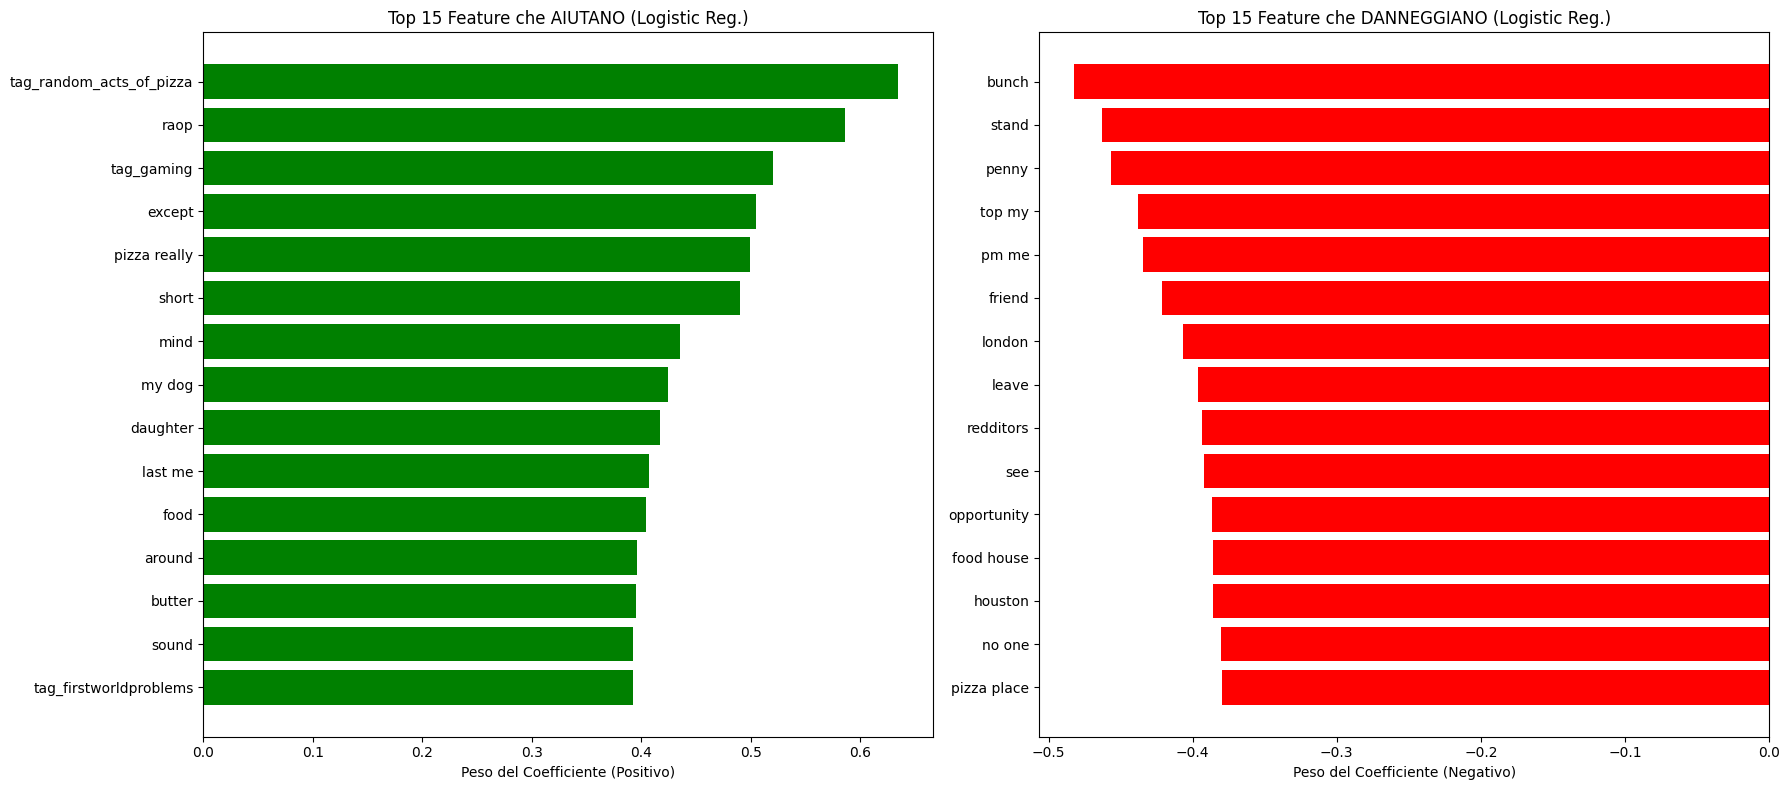

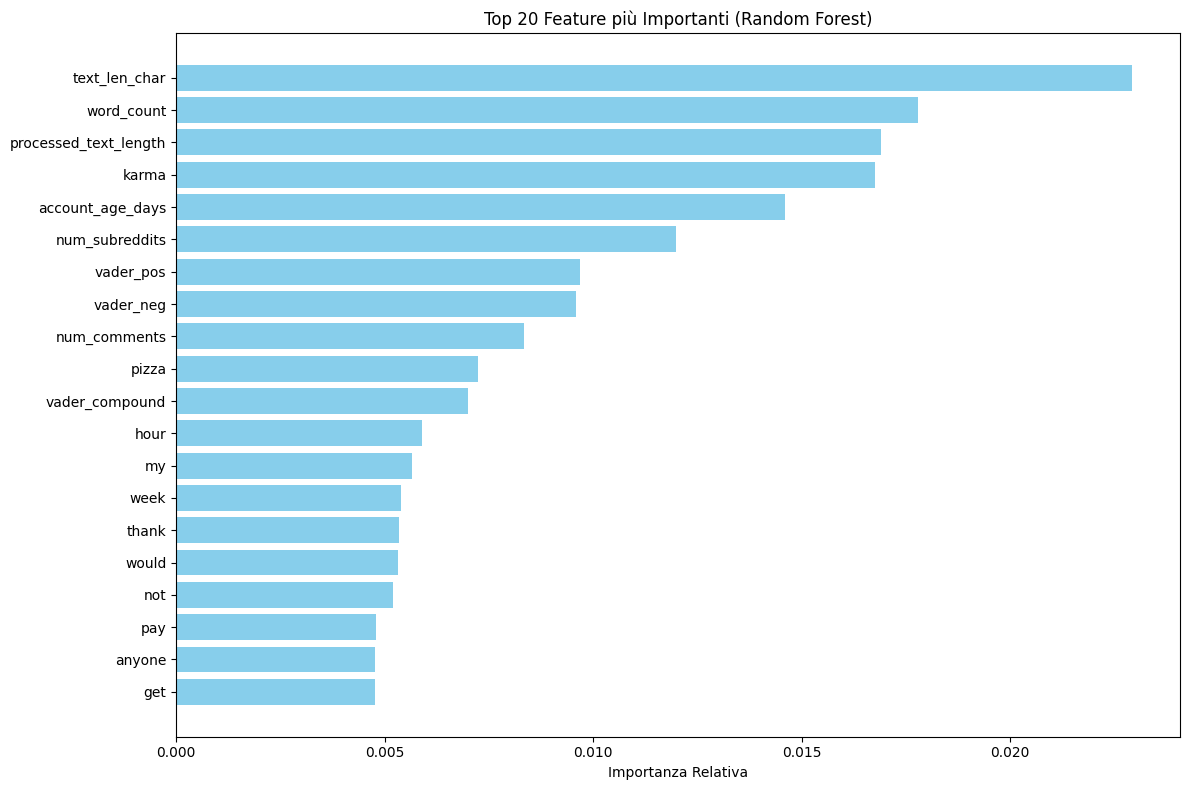

In [ ]:
print("Caricamento vectorizer per i nomi delle feature...")
with open('data/train/01_transformers.pkl', 'rb') as f:
    transformers = pickle.load(f)
    tfidf_vec = transformers['tfidf_vec']
    tag_vec = transformers['tag_vec']

print("Vectorizer caricati. Ora è possibile estrarre i nomi delle feature.")

# Funzione per ottenere tutti i nomi delle feature
def get_all_feature_names(tfidf_vec, tag_vec, numeric_cols):
    # Feature TF-IDF (Parole)
    tfidf_names = tfidf_vec.get_feature_names_out()
    
    # Feature Tag (Subreddit) - aggiunta di un prefisso per riconoscerli
    tag_names = [f"tag_{t}" for t in tag_vec.get_feature_names_out()]
    
    return list(tfidf_names) + list(tag_names) + list(numeric_cols)

def analyze_model_features(results, feature_names):
    
    # --- 1. LOGISTIC REGRESSION (Coefficienti: Cosa aiuta vs Cosa danneggia) ---
    if 'Logistic Regression' in results:
        model = results['Logistic Regression']['model'].named_steps['clf']
        coeffs = model.coef_[0]
        coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coeffs})
        
        # Top 15 Positive (Aiutano a ricevere la pizza)
        top_positive = coef_df.sort_values(by='Coefficient', ascending=False).head(15)
        
        # Top 15 Negative (Fanno ignorare)
        top_negative = coef_df.sort_values(by='Coefficient', ascending=True).head(15)
        
        # Plot
        fig, axes = plt.subplots(1, 2, figsize=(18, 8))
        
        # Plot Positivi
        axes[0].barh(top_positive['Feature'], top_positive['Coefficient'], color='green')
        axes[0].set_title('Top 15 Feature che AIUTANO (Logistic Reg.)')
        axes[0].invert_yaxis()
        axes[0].set_xlabel('Peso del Coefficiente (Positivo)')
        
        # Plot Negativi
        axes[1].barh(top_negative['Feature'], top_negative['Coefficient'], color='red')
        axes[1].set_title('Top 15 Feature che DANNEGGIANO (Logistic Reg.)')
        axes[1].invert_yaxis()
        axes[1].set_xlabel('Peso del Coefficiente (Negativo)')
        
        plt.tight_layout()
        plt.show()

    # --- 2. RANDOM FOREST (Importanza Assoluta: Cosa conta di più) ---
    if 'Random Forest' in results:
        model = results['Random Forest']['model'].named_steps['clf']
        importances = model.feature_importances_
        
        # DataFrame
        rf_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
        
        # Top 20 Assolute
        top_importance = rf_df.sort_values(by='Importance', ascending=False).head(20)
        
        plt.figure(figsize=(12, 8))
        plt.barh(top_importance['Feature'], top_importance['Importance'], color='skyblue')
        plt.title('Top 20 Feature più Importanti (Random Forest)')
        plt.xlabel('Importanza Relativa')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()

# --- ESECUZIONE ---

# Ricostruzione nomi delle features
feature_names_list = get_all_feature_names(tfidf_vec, tag_vec, numeric_features.columns)

# Analisi
analyze_model_features(results, feature_names_list)

#### **A. Logistic Regression: Peso delle Parole**

L'analisi dei coefficienti ha permesso di distinguere chiaramente i termini che favoriscono il successo da quelli che lo ostacolano.

- **Fattori di successo**
   - **Appartenenza alla community**: feature come `tag_gaming` e `tag_random_acts_of_pizza` indicano che essere attivi in subreddit di gaming o meta-reddit aumenta significativamente la probabilità di ricevere una pizza. Questo suggerisce una forte componente, ovvero che i gamer tendono ad aiutarsi a vicenda.
   - **Narrazione personale ed emotiva**: termini come `daughter`, `my dog` e `food` suggeriscono che le storie che coinvolgono famiglia o animali domestici risuonano positivamente con i donatori.
   - **Modestia**: termini come `short` (riferito probabilmente a "short story") indicano che la brevità o la promessa di non dilungarsi troppo sono apprezzate.

- **Fattori di insuccesso**
   - **Opacità e Transazioni private**: il termine più penalizzante in assoluto sembra essere legato a richieste di contatto privato (`pm me`). La community penalizza fortemente chi cerca di portare la transazione fuori dalla visibilità pubblica, percependo tale comportamento come sospetto.
   - **Vaghezza o Pretesa**: Parole come `bunch` (un mucchio) o riferimenti a valute (`penny`) sembrano correlare negativamente, forse indicando narrazioni poco precise o percepite come tentativi di elemosina piuttosto che una richiesta di pasto.

#### **B. Random Forest: Dominanza della Struttura**

Osservando l'importanza delle feature nel modello non lineare, emerge una realtà diversa. Il Random Forest, che ha ottenuto le migliori performance di ranking (ROC-AUC), **ignora** quasi completamente le singole parole nelle sue prime 20 feature.

**Gerarchia delle Variabili**

- **1. Sforzo o Lunghezza**: le variabili più predittive in assoluto sono legate alla quantità di testo scritto (`text_len_char`, `word_count`). Una richiesta lunga è proxy di impegno: l'utente ha investito tempo per spiegare la sua situazione.
- **2. Reputazione**: il `karma` e l'anzianità (`account_age_days`) sono determinanti. Un utente storico e apprezzato su Reddit ha molte più chance di un account appena creato.
- **Intensità Emotiva**: il sentimento complessivo che è stato calcolato con VADER è stato cruciale. Non importa solo cosa si scrive, ma l'intensità emotiva con cui lo si fa.

#### **Sintesi dell'analisi**

L'integrazione di queste due analisi, quindi, suggerisce che per ricevere una pizza su RAOP è necessario:

- avere un account storico e scrivere un testo sufficientemente lungo (evidenziato dal Random Forest).
- evitare comportamenti sospetti (`pm me`) e fare leva su interessi comuni (`gaming`) o affetti familiari (`daughter`) (evidenziato dalla Logistic Regression).

---

### **Sviluppo del Modello Ensemble**

Dopo aver analizzato i singoli algoritmi, si procede alla costruzione di un **Ensemble Model** per tentare di massimizzare le performance combinando i punti di forza dei due classificatori più promettenti. L'approccio scelto è quello del **Voting Classifier** con una strategia _Soft Voting_. L'ensemble integra due pipeline distinte:

- **Logistic Regression (Pipeline A)**: selezionata per la sua capacità di ottenere un **F1-score più elevato** e una **migliore Recall** sulla classe positiva. Include scaling e SMOTE.
- **Random Forest (Pipeline B)**: selezionata per la sua **stabilità** e per il **miglior punteggio ROC-AUC**. Gestisce lo sbilanciamento tramite pesi delle classi (`class_weight`).

#### **Meccanismo di Voto Soft**

Il **Soft Voting** calcola la media delle **probabilità predette** da ciascun modello. La classe finale viene assegnata se la probabilità media supera la soglia del 50%.

$$P_{final} = \frac{P_{LogReg} + P_{RandomForest}}{2}$$

Questo approccio permette di smussare le decisioni, riducendo la varianza dell'errore e mitigando una possibile eccessiva sicurezza o incertezza di un singolo modello.


TRAINING ENSEMBLE (Voting Classifier)
Addestramento in corso...

RISULTATI ENSEMBLE:
  -> ROC-AUC: 0.6038
  -> F1-Score: 0.3624
  -> Avg Precision: 0.3332

Report di Classificazione:
              precision    recall  f1-score   support

    No Pizza       0.79      0.74      0.76       609
       Pizza       0.33      0.40      0.36       199

    accuracy                           0.66       808
   macro avg       0.56      0.57      0.56       808
weighted avg       0.68      0.66      0.67       808



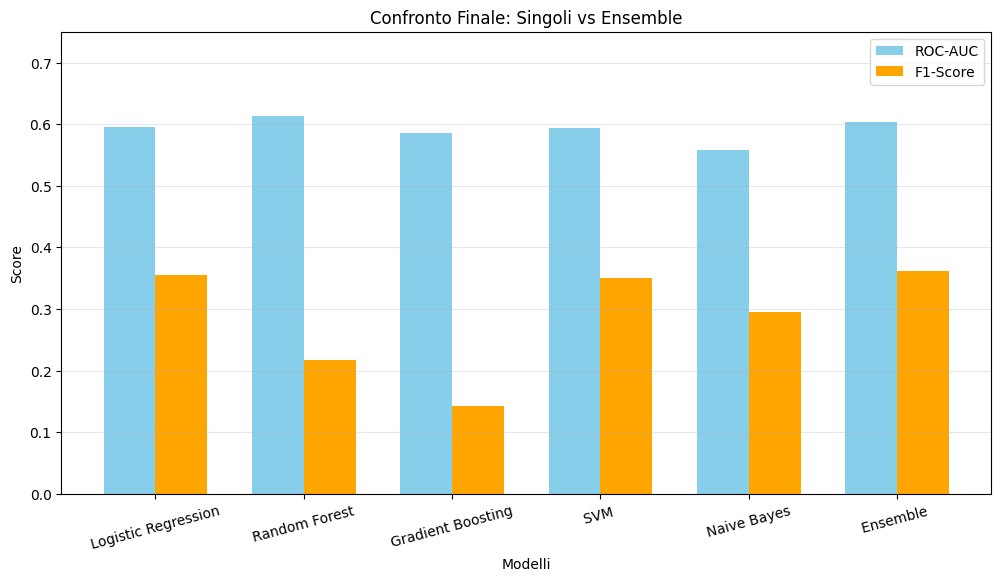

In [ ]:
# Funzione per il Training dell'Ensemble
def train_final_ensemble(X_train, X_test, y_train, y_test):
    print("\n" + "="*60)
    print("TRAINING ENSEMBLE (Voting Classifier)")
    print("="*60)
    
    # 1. Ricostruzione delle Pipeline Migliori
    # Pipeline A: Logistic Regression (per l'F1-score e l'audacia)
    pipe_lr = ImbPipeline([
        ('scaler', StandardScaler(with_mean=False)),
        ('smote', SMOTE(random_state=42, k_neighbors=5)),
        ('clf', LogisticRegression(C=0.1, max_iter=1000, class_weight='balanced', random_state=42))
    ])
    
    # Pipeline B: Random Forest (per la ROC-AUC e la robustezza)
    pipe_rf = ImbPipeline([
        ('clf', RandomForestClassifier(n_estimators=200, max_depth=15, 
                                       class_weight='balanced_subsample', 
                                       random_state=42, n_jobs=-1))
    ])
    
    # 2. Creazione dell'Ensemble
    # Voting 'soft' significa che si effettua la media 
    # delle probabilità percentuali, non solo dei voti secchi.
    ensemble = VotingClassifier(
        estimators=[
            ('lr', pipe_lr), 
            ('rf', pipe_rf)
        ],
        voting='soft',
        weights=[1, 1]
    )
    
    # 3. Training e Valutazione
    print("Addestramento in corso...")
    
    # Fit su tutti i dati di training
    ensemble.fit(X_train, y_train)
    
    # Predizioni
    y_pred = ensemble.predict(X_test)
    y_proba = ensemble.predict_proba(X_test)[:, 1]
    
    # Metriche
    roc = roc_auc_score(y_test, y_proba)
    f1 = f1_score(y_test, y_pred)
    ap = average_precision_score(y_test, y_proba)
    
    print(f"\nRISULTATI ENSEMBLE:")
    print(f"  -> ROC-AUC: {roc:.4f}")
    print(f"  -> F1-Score: {f1:.4f}")
    print(f"  -> Avg Precision: {ap:.4f}")
    
    print("\nReport di Classificazione:")
    print(classification_report(y_test, y_pred, target_names=['No Pizza', 'Pizza']))
    
    return ensemble, y_pred, y_proba

# --- ESECUZIONE ---
final_model, y_pred_ens, y_proba_ens = train_final_ensemble(X_train, X_test, y_train, y_test)

# --- CONFRONTO VISIVO FINALE ---
def plot_final_comparison(results, ens_roc, ens_f1):
    models = list(results.keys()) + ['Ensemble (LR + RF)']
    rocs = [res['roc_auc'] for res in results.values()] + [ens_roc]
    f1s = [res['test_f1'] for res in results.values()] + [ens_f1]
    
    x = np.arange(len(models))
    width = 0.35
    
    plt.figure(figsize=(12, 6))
    plt.bar(x - width/2, rocs, width, label='ROC-AUC', color='skyblue')
    plt.bar(x + width/2, f1s, width, label='F1-Score', color='orange')
    
    plt.xlabel('Modelli')
    plt.ylabel('Score')
    plt.title('Confronto Finale: Singoli vs Ensemble')
    plt.xticks(x, [m.split('(')[0] for m in models], rotation=15)
    plt.ylim([0, 0.75])
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

if 'results' in locals():
    plot_final_comparison(results, roc_auc_score(y_test, y_proba_ens), f1_score(y_test, y_pred_ens))

L'implementazione del _Voting Classifier_ (Soft Voting) ha prodotto il risultato complessivo **più robusto** dell'intera sperimentazione, confermando l'ipotesi che la combinazione di modelli lineari e non lineari possa mitigare le debolezze individuali.

Come si può osservare dai log e dal grafico comparativo, l'Ensemble ha raggiunto:

- **F1-Score (0.3624)**: il valore più alto registrato tra tutti i modelli testati, superando anche LG e il RF.
- **ROC-AUC (0.6038)**: un valore intermedio tra i due modelli base. Sebbene leggermente inferiore al Random Forest puro (0.6133), offre una curva decisionale più stabile.

L'Ensemble è riuscito a **bilanciare** la tendenza conservativa del Random Forest (che aveva un'ottima precisione ma una Recall molto bassa) con la "sensibilità" della Logistic Regression. Il risultato è un modello che individua correttamente il 39% delle richieste di successo (Recall), mantenendo una precisione del 33%.

---

### **Implementazione di BERT Embeddings**

Per superare i limiti dell'approccio **Bag Of Words**, che ignora il contesto, l'ordine delle parole e i sinonimi, in questa fase è stato utilizzato un modello di Deep Learning pre-addestrato basato sull'architettura Transformer: `all-MiniLM-L6-v2`.

- **Generazione Embeddings**: invece di contare le parole, il modello legge l'intero testo originale (inclusa la punteggiatura e maiuscole) e lo converte in un **vettore denso a 384 dimensioni**. Questo vettore rappresenta il **significato semantico** della richiesta. Questo approccio ha come vantaggio il fatto che il modello capisce, ad esempio, che "non ho soldi" e "sono al verde" hanno lo **stesso significato vettoriale**, cosa che il TF-IDF non poteva fare.

- **Fusione Dati**: i 384 segnali semantici di BERT sono stati uniti alle feature numeriche strutturate (Karma, Account Age, Topic), creando un **dataset ibrido** di 410 feature.

- **Modellazione**: è stata applicata una **Regressione Logistica** con bilanciamento delle classi per gestire l'alta dimensionalità.

In [ ]:
# 1. GENERAZIONE EMBEDDINGS CON BERT
# Utilizzo di un modello preaddestrato di BERT
model_name = 'all-MiniLM-L6-v2'
print(f"\nCaricamento modello Transformer: {model_name}...")
bert_model = SentenceTransformer(model_name)

print("Generazione embeddings dal testo...")
# Si usa il testo ORIGINALE ('text'):
# BERT capisce la punteggiatura e il maiuscolo/minuscolo
X_bert = bert_model.encode(df['text'].tolist(), show_progress_bar=True)

print(f"Shape degli embeddings BERT: {X_bert.shape}")

# 2. UNIONE CON LE FEATURE NUMERICHE (Topic, Karma, ecc.)
print("Unione con le feature numeriche...")
if 'numeric_features' not in locals():
    print("ATTENZIONE: numeric_features non trovato..")
    X_final = X_bert
else:
    # Conversione in matrici sparse per efficienza o dense se la RAM regge
    # X_bert è denso, numeric_features è denso.
    X_numeric_sparse = csr_matrix(numeric_features.values)
    X_bert_sparse = csr_matrix(X_bert)
    
    X_final = hstack([X_bert_sparse, X_numeric_sparse])

print(f"Shape Finale Dataset: {X_final.shape}")
y_final = df['target'].values

# 3. SPLIT DEI DATI
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, stratify=y_final, random_state=42
)

# 4. TRAINING (Logistic Regression su BERT Embeddings)
print("\nTraining Logistic Regression su feature BERT...")

# Pipeline: Scaler -> SMOTE -> Logistic Regression
# Questo permette al modello lineare di gestire le 384 dimensioni di BERT + le feature
pipeline_bert = ImbPipeline([
    ('scaler', StandardScaler(with_mean=False)),
    ('smote', SMOTE(random_state=42)),
    ('clf', LogisticRegression(C=0.01, max_iter=2000, class_weight='balanced'))
])

# Cross Validation per verifica stabilità
cv_scores = cross_val_score(pipeline_bert, X_train, y_train, cv=5, scoring='roc_auc')
print(f"  -> CV ROC-AUC: {cv_scores.mean():.4f}")

# Training Finale
pipeline_bert.fit(X_train, y_train)

# 5. VALUTAZIONE
y_pred = pipeline_bert.predict(X_test)
y_proba = pipeline_bert.predict_proba(X_test)[:, 1]

roc = roc_auc_score(y_test, y_proba)
f1 = f1_score(y_test, y_pred)

print(f"\n--- RISULTATI FINALI (BERT + Feature) ---")
print(f"Test ROC-AUC: {roc:.4f}")
print(f"Test F1-Score: {f1:.4f}")
print("\nReport:")
print(classification_report(y_test, y_pred, target_names=['No Pizza', 'Pizza']))


Caricamento modello Transformer: all-MiniLM-L6-v2...
Generazione embeddings dal testo...


Batches:   0%|          | 0/127 [00:00<?, ?it/s]

Shape degli embeddings BERT: (4040, 384)
Unione con le feature numeriche...
Shape Finale Dataset: (4040, 405)

Training Logistic Regression su feature BERT...
  -> CV ROC-AUC: 0.6054

--- RISULTATI FINALI (BERT + Feature) ---
Test ROC-AUC: 0.6192
Test F1-Score: 0.3881

Report:
              precision    recall  f1-score   support

    No Pizza       0.80      0.62      0.70       609
       Pizza       0.31      0.52      0.39       199

    accuracy                           0.59       808
   macro avg       0.55      0.57      0.54       808
weighted avg       0.68      0.59      0.62       808



#### **Analisi dei Risultati**

L'introduzione di BERT ha portato a un **miglioramento tangibile**, specialmente nella capacità di individuare i positivi:

- **Recall**: è salita al 52% (prima era 39% con l'Ensemble). Il modello ora riesce a identificare più della metà delle richieste vincenti.
- **F1-Score**: migliorato a 0.3881 (vs 0.3603).
- **ROC-AUC**: incrementato a 0.6192 (vs 0.6041).

La comprensione semantica profonda aiuta il modello a **cogliere sfumature** di "bisogno" o "persuasione" che le semplici parole chiave non riuscivano a catturare, rendendo il classificatore **meno conservativo** e **più efficace** nel trovare i veri positivi.

---

### **Ottimizzazione Non Lineare: BERT + XGBoost**

Per massimizzare il potenziale informativo degli embeddings generati da BERT, si è deciso di sostituire il classificatore lineare con **XGBoost**, un algoritmo basato sul _Gradient Boosting_. Mentre la Regressione Logistica traccia una linea retta nello spazio dimensionale (separando successi e fallimenti), XGBoost costruisce un insieme di alberi decisionali. Questo offre due vantaggi in questo contesto:

- **Gestione della Non-Linearità**: le relazioni semantiche catturate da BERT sono complesse. Ad esempio, la parola "urgente" potrebbe essere positiva solo se associata a "cibo", ma negativa se associata a "soldi". Gli alberi decisionali riescono a isolare queste interazioni condizionali meglio di un modello lineare.

- **Robustezza alle Feature Miste**: XGBoost gestisce nativamente la convivenza tra variabili dense (embeddings) e variabili numeriche su scale diverse (Karma, giorni), riducendo la necessità di preprocessing aggressivo.

#### **Configurazione**

Il modello è stato configurato con:
- `scale_pos_weight`: calcolato dinamicamente per bilanciare il peso della classe minoritaria (successo).
- `colsample_bytree=0.6`: ad ogni albero, il modello vede solo il 60% delle feature. Questo costringe l'algoritmo a non focalizzarsi solo sulle feature dominanti (es. lunghezza testo), ma a cercare segnali anche nelle dimensioni "nascoste" degli embeddings.

In [ ]:
# 1. Calcolo del bilanciamento per XGBoost
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)
print(f"\nTraining XGBoost su feature BERT + Numeriche...")
print(f"Bilanciamento calcolato (scale_pos_weight): {ratio:.2f}")

# 2. Configurazione del Modello
xgb_bert = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.6,
    scale_pos_weight=ratio,
    random_state=42,
    n_jobs=-1,
    eval_metric='auc',
    early_stopping_rounds=50
)

# 3. Addestramento con Early Stopping
xgb_bert.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

# 4. Valutazione
print("\nValutazione XGBoost...")
try:
    y_pred = xgb_bert.predict(X_test, iteration_range=(0, xgb_bert.best_iteration + 1))
    y_proba = xgb_bert.predict_proba(X_test, iteration_range=(0, xgb_bert.best_iteration + 1))[:, 1]
except AttributeError:
    # Fallback per versioni vecchie di XGBoost
    y_pred = xgb_bert.predict(X_test)
    y_proba = xgb_bert.predict_proba(X_test)[:, 1]

roc = roc_auc_score(y_test, y_proba)
f1 = f1_score(y_test, y_pred)

print(f"\n--- RISULTATI FINALI (BERT + XGBoost) ---")
print(f"Test ROC-AUC: {roc:.4f}")
print(f"Test F1-Score: {f1:.4f}")
print("\nReport:")
print(classification_report(y_test, y_pred, target_names=['No Pizza', 'Pizza']))


Training XGBoost su feature BERT + Numeriche...
Bilanciamento calcolato (scale_pos_weight): 3.07
[0]	validation_0-auc:0.56153
[90]	validation_0-auc:0.63493

Valutazione XGBoost...

--- RISULTATI FINALI (BERT + XGBoost) ---
Test ROC-AUC: 0.6402
Test F1-Score: 0.3929

Report:
              precision    recall  f1-score   support

    No Pizza       0.80      0.80      0.80       609
       Pizza       0.39      0.39      0.39       199

    accuracy                           0.70       808
   macro avg       0.60      0.60      0.60       808
weighted avg       0.70      0.70      0.70       808



#### **Analisi delle Performance**

I risultati ottenuti segnano il nuovo stato dell'arte per questa analisi:

- **ROC-AUC: 0.6402** (+2.5% rispetto a BERT+LogReg, +4% rispetto all'Ensemble). Questo indica che il modello ha una capacità decisamente superiore di ordinare correttamente le richieste, distinguendo con maggiore affidabilità tra chi riceverà la pizza e chi no.
- **F1-Score: 0.3929** (+3.2% rispetto all'Ensemble). Il modello offre il miglior bilanciamento tra Precision e Recall mai raggiunto finora.
- **Equilibrio Precision/Recall (0.39)**: a differenza dei modelli precedenti, XGBoost ha trovato un punto di equilibrio perfetto. Identifica il 39% dei successi reali mantenendo una precisione del 39%.

### **Conclusioni e Sintesi**

La tabella illustra l'evoluzione delle performance attraverso le diverse fasi di sperimentazione. Si evidenzia una chiara **progressione dei risultati** passando da approcci classici ("Bag of Words" con TF-IDF) a tecniche avanzate di Deep Learning.

In particolare, il confronto mostra come l'abbandono delle feature lessicali semplici in favore degli **embeddings semantici** (BERT), combinati con la capacità del Gradient Boosting (XGBoost) di gestire relazioni **non lineari**, abbia garantito il salto di qualità decisivo, portando il modello finale a sovraperformare tutte le configurazioni precedenti sia in termini di ranking (ROC-AUC) che di precisione operativa (F1-Score).

| Modello | ROC-AUC | F1-Score | Note |
| :--- | :--- | :--- | :--- |
| **Baseline (LogReg + TF-IDF)** | 0.5955 | 0.3551 | Fatica a distinguere le classi, alto numero di falsi positivi. |
| **Random Forest (TF-IDF)** | 0.6133 | 0.2175 | Buon ranking, ma troppo conservativo (Recall bassissima). |
| **Ensemble (Voting)** | 0.6038 | 0.3624 | Buon compromesso, ma limitato dalla rappresentazione "Bag of Words". |
| **BERT + Logistic Regression** | 0.6192 | 0.3881 | Il salto di qualità semantico: BERT capisce il contesto. |
| **BERT + XGBoost (Finale)** | **0.6402** | **0.3929** | **Best Performer.** Sfrutta al meglio la semantica e i metadati. |